# Численное решение редуцированной системы Ланга–Кобаяши в полярных координатах

## Математическая постановка

Рассматривается редуцированная система дифференциальных уравнений с запаздыванием, записанная в полярных переменных

$$
E(t)=R(t)e^{i\theta(t)},
$$

где:

- $R(t)$ — амплитуда поля;
- $\theta(t)$ — фаза поля.

После перехода к полярным координатам система принимает вид

$$
\frac{dR}{dt}
=
v\left(\frac{1}{R}-R\right)
+
\gamma R(t-h)\cos\Phi(t),
$$

$$
\frac{d\theta}{dt}
=
v\alpha\left(\frac{1}{R^2}-1\right)
-
\gamma\frac{R(t-h)}{R(t)}
\sin\Phi(t),
$$

где

$$
\Phi(t)=\theta(t)-\theta(t-h)-\omega_0 h.
$$

Запаздывание входит через значения амплитуды и фазы в момент времени $t-h$.

Таким образом система относится к классу дифференциальных уравнений с запаздывающим аргументом (DDE).

## Используемые параметры модели

### Параметры динамической системы

| Параметр | Смысл |
|-----------|-----------|
| $\gamma$ | коэффициент обратной связи |
| $v$ | параметр релаксации амплитуды |
| $\alpha$ | коэффициент связи амплитуды и фазы |
| $h$ | время запаздывания |

Дополнительно вычисляются

$$
\varphi_0=\arctan(\alpha),
$$

$$
\omega_0=\frac{\varphi_0}{h}.
$$

## Численный метод

Для интегрирования используется классическая схема Рунге–Кутты четвёртого порядка (RK4).

На каждом шаге требуется вычислять значения

$$
R(t-h), \qquad \theta(t-h),
$$

которые обычно не совпадают с узлами сетки.

Поэтому применяется кубическая интерполяция Эрмита.

### Интерполяция Эрмита

Для восстановления значения функции между узлами используются:

- значения функции;
- значения её производной.

Это обеспечивает более высокую точность по сравнению с линейной интерполяцией и особенно важно при вычислении запаздывающих членов.

## Параметры численного интегрирования

| Параметр | Значение |
|-----------|-----------|
| $t_{max}$ | 1000 |
| $dt$ | $10^{-3}$ |
| переходный процесс | первые 500 единиц времени |

Вычисления производятся на равномерной временной сетке

$$
t_n=n\,dt.
$$

После завершения интегрирования начальная часть траектории отбрасывается как переходный процесс.

## Выходные данные

### Амплитуда

$$
R(t).
$$

### Фаза

$$
\theta(t).
$$

### Интенсивность

$$
I(t)=R^2(t).
$$

### Мгновенная частота

$$
\omega(t)=\frac{d\theta}{dt}.
$$

### Производная интенсивности

$$
\frac{dI}{dt}.
$$

## Основные массивы данных

| Массив | Содержимое |
|---------|---------|
| `t` | временная сетка |
| `R` | амплитуда |
| `theta` | фаза |
| `I_plot` | интенсивность |
| `omega_inst` | мгновенная частота |
| `dI` | производная интенсивности |

## Типичные объекты исследования

- временные реализации $R(t)$, $I(t)$, $\theta(t)$;
- фазовые портреты $(I,\dot I)$;
- трёхмерные вложения задержки;
- спектры мощности;
- бифуркационные диаграммы;
- показатели Ляпунова;
- исследование влияния параметров и функции истории на динамику системы.


# Настройка вычислительного эксперимента

Перед запуском расчёта пользователь может изменять параметры математической модели, параметры численного интегрирования и функцию истории.

---

# 1. Параметры математической модели

Основные параметры системы задаются в начале программы:

```python
gamma = 4.0
h = 1.605

v = 10.0
alpha = 5.0
```

### Коэффициент обратной связи

```python
gamma
```

Параметр определяет силу запаздывающей обратной связи.

При увеличении `gamma` влияние прошлых состояний системы усиливается.

Во многих задачах именно изменение `gamma` приводит к переходам между:

* стационарными режимами;
* периодическими колебаниями;
* квазипериодическими режимами;
* хаотической динамикой.

---

### Время запаздывания

```python
h
```

Задаёт величину временной задержки в системе.

В уравнения входят значения

$
R(t-h),
\qquad
\theta(t-h).
$

Увеличение задержки обычно приводит к росту размерности динамики и усложнению поведения системы.

---

### Параметр релаксации

```python
v
```

Определяет скорость возвращения амплитуды к стационарному состоянию.

Большие значения соответствуют более быстрой релаксации.

---

### Коэффициент связи амплитуды и фазы

```python
alpha
```

Определяет степень влияния изменений амплитуды на фазовую динамику.

Дополнительно вычисляются

$
\varphi_0=\arctan(\alpha),
$

$
\omega_0=\frac{\varphi_0}{h}.
$


---

# 2. Параметры численного интегрирования

Следующие параметры влияют только на точность вычислений и длительность моделирования.

```python
t_max = 1000.0
dt = 1e-3
transient_cut = 500.0
```

---

### Время моделирования

```python
t_max
```

Определяет конечный момент времени расчёта.

Интервал интегрирования имеет вид

$
0 \le t \le t_{max}.
$

Для анализа асимптотических режимов рекомендуется выбирать большие значения.

---

### Шаг интегрирования

```python
dt
```

Задаёт шаг временной сетки.

Меньшие значения обеспечивают более высокую точность, но требуют большего времени вычислений.

Типичные значения:

```python
dt = 1e-2
```

```python
dt = 1e-3
```

или

```python
dt = 5e-4
```

---

### Отбрасывание переходного процесса

```python
transient_cut
```

Начальный участок траектории не используется при анализе.

После завершения расчёта сохраняются только точки

$
t > transient_cut.
$

Это позволяет исследовать установившийся режим.

---

# 3. Функция истории

Поскольку система содержит запаздывание, необходимо определить состояние на интервале

$
[-h,0].
$

В программе это задаётся функцией

```python
def history_function(t):
```

---

## Текущий вариант истории

```python
history_amp = 0.1
history_freq = 0.15
history_phase = 0.3

def history_function(t):

    R_hist = history_amp * (
        1.0
        + 0.05 * np.cos(
            2 * np.pi * history_freq * t
        )
    )

    theta_hist = (
        omega0 * t
        + history_phase
        + 0.02 * np.sin(0.7 * t)
    )

    return R_hist, theta_hist
```

---

### Амплитуда истории

Задаётся функцией

$$
R(t)= A
\left(
1+0.05\cos(2\pi f t)
\right),
$$

где

```python
history_amp = A
history_freq = f
```

---

### Параметр history_amp

```python
history_amp
```

Определяет общий масштаб начальной амплитуды.

Например:

```python
history_amp = 0.01
```

очень малая начальная амплитуда,

```python
history_amp = 10
```

большая начальная амплитуда.

---

### Параметр history_freq

```python
history_freq
```

Определяет частоту колебаний начальной функции истории.

Увеличение параметра приводит к более быстрым осцилляциям на интервале

$
[-h,0].
$

---

### Параметр history_phase

```python
history_phase
```

Добавляет постоянный фазовый сдвиг к начальной фазе.

---

# 4. Изменение функции истории

Для исследования чувствительности к начальным условиям рекомендуется менять функцию

```python
history_function()
```

Например:

### Постоянная история

```python
R_hist = 1.0
theta_hist = omega0 * t
```

---

### Гармоническая история

```python
R_hist = 1 + 0.3*np.cos(5*t)
```

---

### Случайная история

```python
R_hist = 1 + 0.05*rng.normal()
```

---

### Кусочно-постоянная история

```python
if t < -h/2:
    R_hist = 2
else:
    R_hist = 10
```

Сравнение решений для различных историй позволяет исследовать наличие мультистабильности и чувствительности к начальным условиям.

---

# 5. Основные результаты расчёта

После выполнения вычислений доступны массивы

```python
t
R
theta
```

Из них дополнительно формируются

```python
I = R**2
```

— интенсивность,

```python
omega_inst
```

— мгновенная частота,

```python
dI
```

— производная интенсивности.

Эти величины используются для построения временных реализаций, фазовых портретов, спектров мощности, реконструкции аттракторов и анализа хаотической динамики.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import windows
from mpl_toolkits.mplot3d import Axes3D

gamma = 4.0
h = 1.605

v = 10.0
alpha = 5.0

phi0 = np.arctan(alpha)
omega0 = phi0 / h

t_max = 1000.0
dt = 1e-2
transient_cut = 500.0

history_amp = 0.1
history_freq = 0.15
history_phase = 0.3

eps = 1e-12


def history_function(t):

    R_hist = history_amp * (
        1.0
        + 0.05 * np.cos(
            2 * np.pi * history_freq * t
        )
    )

    theta_hist = (
        omega0 * t
        + history_phase
        + 0.02 * np.sin(0.7 * t)
    )

    return R_hist, theta_hist


def solve_reduced_polar():

    n_steps = int(np.ceil(t_max / dt))

    t_arr = np.linspace(
        0.0,
        t_max,
        n_steps + 1
    )

    R_arr = np.zeros(n_steps + 1)
    theta_arr = np.zeros(n_steps + 1)

    dR_arr = np.zeros(n_steps + 1)
    dtheta_arr = np.zeros(n_steps + 1)

    R0, theta0 = history_function(0.0)

    R_arr[0] = R0
    theta_arr[0] = theta0

    def rhs(
        R,
        theta,
        R_delay,
        theta_delay
    ):

        phase = (
            theta
            - theta_delay
            - omega0 * h
        )

        cos_p = np.cos(phase)
        sin_p = np.sin(phase)

        R_safe = max(R, eps)

        dR = (
            v * (1.0 / R_safe - R)
            + gamma * R_delay * cos_p
        )

        dtheta = (
            v * alpha * (
                1.0 / R_safe**2 - 1.0
            )
            - gamma
            * (R_delay / R_safe)
            * sin_p
        )

        return dR, dtheta

    def hermite_interp(
        arr,
        darr,
        t_query,
        current_n
    ):

        if t_query <= 0.0:
            return None

        pos = t_query / dt

        i = int(np.floor(pos))

        if i >= current_n:
            i = current_n - 1

        if i < 0:
            i = 0

        s = (t_query - i * dt) / dt

        h00 = 2 * s**3 - 3 * s**2 + 1
        h10 = s**3 - 2 * s**2 + s
        h01 = -2 * s**3 + 3 * s**2
        h11 = s**3 - s**2

        return (
            h00 * arr[i]
            + h10 * dt * darr[i]
            + h01 * arr[i + 1]
            + h11 * dt * darr[i + 1]
        )

    def delayed_values(
        t_query,
        current_n
    ):

        if t_query <= 0.0:
            return history_function(t_query)

        R_d = hermite_interp(
            R_arr,
            dR_arr,
            t_query,
            current_n
        )

        th_d = hermite_interp(
            theta_arr,
            dtheta_arr,
            t_query,
            current_n
        )

        return R_d, th_d

    R_d0, th_d0 = history_function(-h)

    dR0, dth0 = rhs(
        R_arr[0],
        theta_arr[0],
        R_d0,
        th_d0
    )

    dR_arr[0] = dR0
    dtheta_arr[0] = dth0

    for n in range(n_steps):

        t = t_arr[n]

        R = R_arr[n]
        theta = theta_arr[n]

        R_d, th_d = delayed_values(
            t - h,
            n
        )

        k1R, k1th = rhs(
            R,
            theta,
            R_d,
            th_d
        )

        R2 = R + 0.5 * dt * k1R
        th2 = theta + 0.5 * dt * k1th

        R_d, th_d = delayed_values(
            t + 0.5 * dt - h,
            n
        )

        k2R, k2th = rhs(
            R2,
            th2,
            R_d,
            th_d
        )

        R3 = R + 0.5 * dt * k2R
        th3 = theta + 0.5 * dt * k2th

        k3R, k3th = rhs(
            R3,
            th3,
            R_d,
            th_d
        )

        R4 = R + dt * k3R
        th4 = theta + dt * k3th

        R_d, th_d = delayed_values(
            t + dt - h,
            n
        )

        k4R, k4th = rhs(
            R4,
            th4,
            R_d,
            th_d
        )

        R_arr[n + 1] = (
            R
            + dt / 6.0
            * (
                k1R
                + 2 * k2R
                + 2 * k3R
                + k4R
            )
        )

        theta_arr[n + 1] = (
            theta
            + dt / 6.0
            * (
                k1th
                + 2 * k2th
                + 2 * k3th
                + k4th
            )
        )

        dR_arr[n] = k1R
        dtheta_arr[n] = k1th

    return t_arr, R_arr, theta_arr


t, R, theta = solve_reduced_polar()

mask = t > transient_cut

t_plot = t[mask]
R_plot = R[mask]
theta_plot = theta[mask]

I_plot = R_plot**2

theta_unw = np.unwrap(theta_plot)

omega_inst = np.gradient(
    theta_unw,
    dt
)

dI = np.gradient(
    I_plot,
    dt
)

# Анализ динамики системы

После численного решения уравнений Ланга–Кобаяши вычисляются несколько диагностических представлений траектории, позволяющих исследовать структуру колебаний, наличие периодичности, квазипериодичности и хаоса.

---

# Временные реализации

Строятся зависимости интенсивности

$$
I(t)=R^2(t)
$$

и мгновенной частоты

$$
\omega(t)=\frac{d\theta}{dt}.
$$

Интенсивность характеризует изменение мощности излучения во времени.

Мгновенная частота отражает скорость изменения фазы и позволяет выявлять частотную модуляцию, синхронизацию и переходы между различными динамическими режимами.

Для удобства анализа обычно отображается только конечный участок траектории после удаления переходного процесса.

---

# Портрет $(I,\Delta\theta)$

Для исследования совместной динамики амплитуды и фазы строится фазовый портрет

$$
(I,\Delta\theta),
$$

где

$$
I(t)=R^2(t),
$$

а

$$
\Delta\theta(t)
=
\theta(t)-\theta(t-h).
$$

Величина

$$
\Delta\theta
$$

представляет собой фазовый набег за время задержки.

Такое представление позволяет исследовать структуру аттрактора в переменных, непосредственно связанных с механизмом запаздывающей обратной связи.

Типичные признаки:

- одна точка — стационарный режим;
- замкнутая кривая — периодический режим;
- несколько замкнутых кривых — квазипериодический режим;
- сложная фрактальная область — хаотическая динамика.

---

# Двумерное вложение задержки

Для реконструкции фазового пространства используется метод вложения задержки.

Строится отображение

$$
(I(t),I(t-h)).
$$

Согласно теореме Такенса, информация о динамике системы может быть восстановлена по одной наблюдаемой величине при использовании её задержанных значений.

В данном случае наблюдаемой величиной является интенсивность

$$
I(t).
$$

Такой портрет позволяет визуализировать структуру аттрактора без использования всех переменных модели.

---

# Трёхмерное вложение задержки

Для более полной реконструкции фазового пространства строится трёхмерное вложение

$$
(I(t),I(t-h),I(t-2h)).
$$

Каждая точка пространства определяется значениями интенсивности в трёх различных моментах времени.

Получаемое множество является приближённой реконструкцией аттрактора исходной динамической системы.

Трёхмерное вложение особенно полезно для:

- визуализации хаотических аттракторов;
- поиска периодических орбит;
- исследования топологии фазового пространства;
- качественного сравнения различных режимов генерации.

---

# Спектральный анализ

Для исследования частотного состава сигнала вычисляется спектр мощности интенсивности.

Предварительно из сигнала удаляется среднее значение:

$$
\widetilde I(t)
=
I(t)-\langle I\rangle.
$$

После этого применяется окно Ханна

$$
I_w(t)
=
w(t)\widetilde I(t),
$$

что уменьшает спектральные утечки.

Далее вычисляется быстрое преобразование Фурье

$$
\widehat I(f)
=
\mathcal F\{I_w(t)\}.
$$

Спектральная мощность определяется как

$$
S(f)
=
|\widehat I(f)|^2.
$$

---

# Логарифмический спектр

Спектр дополнительно отображается в логарифмическом масштабе по оси мощности.

Такое представление позволяет выявлять слабые спектральные компоненты, которые могут быть незаметны на линейной шкале.

Для различных режимов характерны следующие признаки:

### Стационарное состояние

В спектре присутствует один основной пик около нулевой частоты.

### Периодические колебания

Наблюдаются дискретные спектральные линии:

$$
f_0,\;2f_0,\;3f_0,\dots
$$

### Квазипериодический режим

Появляются две и более несоизмеримые фундаментальные частоты и их линейные комбинации.

### Хаотический режим

Возникает широкий непрерывный спектр с большим количеством частотных компонент.

---

# Назначение диагностик

Каждое представление характеризует систему с различной точки зрения:

| График | Назначение |
|----------|----------|
| $$I(t)$$ | временная динамика интенсивности |
| $$\omega(t)=d\theta/dt$$ | частотная динамика |
| $$(I,\Delta\theta)$$ | совместная амплитудно-фазовая динамика |
| $$(I(t),I(t-h))$$ | двумерная реконструкция аттрактора |
| $$(I(t),I(t-h),I(t-2h))$$ | трёхмерная реконструкция аттрактора |
| $$S(f)$$ | частотный анализ сигнала |

Совместное использование этих диагностик позволяет исследовать структуру аттрактора, обнаруживать бифуркации и различать периодические, квазипериодические и хаотические режимы генерации.

# Настройка отображаемого временного интервала

На графиках временных реализаций используется команда

```python
plt.xlim(980, 1000)
```

Она задаёт отображаемый диапазон времени

$$
980 \le t \le 1000.
$$

Таким образом на графике показывается только конечный участок траектории.

---

## Зачем это необходимо

Расчёт выполняется на интервале

$$
0 \le t \le t_{max}.
$$

При стандартных параметрах

$$
t_{max}=1000
$$

и

$$
dt=10^{-3},
$$

число вычисленных точек составляет порядка миллиона.

Если отображать весь временной ряд сразу, то:

- отдельные колебания становятся неразличимыми;
- хаотическая траектория превращается в плотную полосу;
- мелкие детали динамики теряются.

Поэтому обычно исследуется небольшой участок установившегося режима.

---

## Как изменить масштаб

Для просмотра другого участка траектории можно изменить границы:

```python
plt.xlim(900, 920)
```

или

```python
plt.xlim(995, 1000)
```

Если интересует вся история моделирования, можно полностью удалить строку

```python
plt.xlim(...)
```

или использовать

```python
plt.xlim(0, t_max)
```

---

## Рекомендации

Для хаотических режимов полезно просматривать несколько масштабов одновременно:

### Глобальная картина

```python
plt.xlim(0, t_max)
```

Показывает поведение системы на всём интервале моделирования.

### Средний масштаб

```python
plt.xlim(900, 1000)
```

Позволяет исследовать изменение амплитуды колебаний.

### Локальный масштаб

```python
plt.xlim(995, 1000)
```

Позволяет различать отдельные осцилляции и анализировать их структуру.

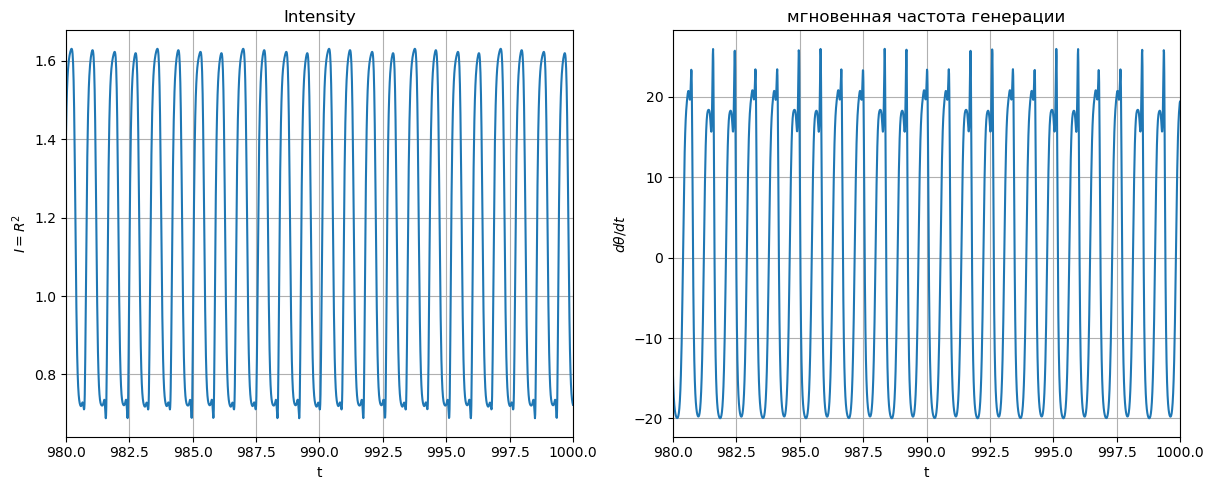

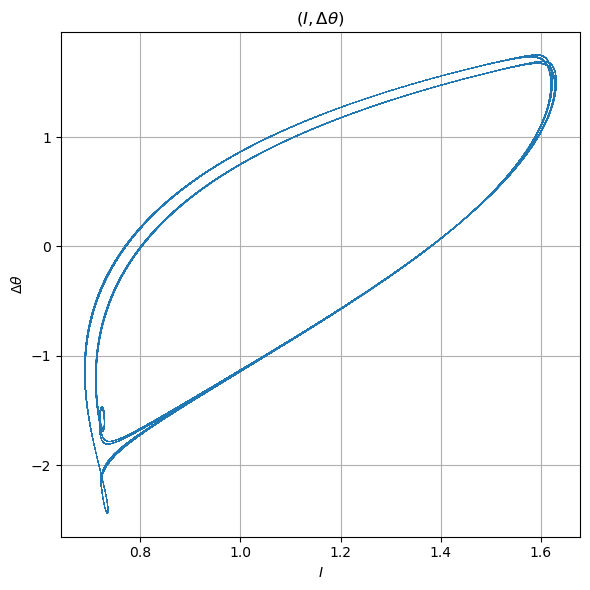

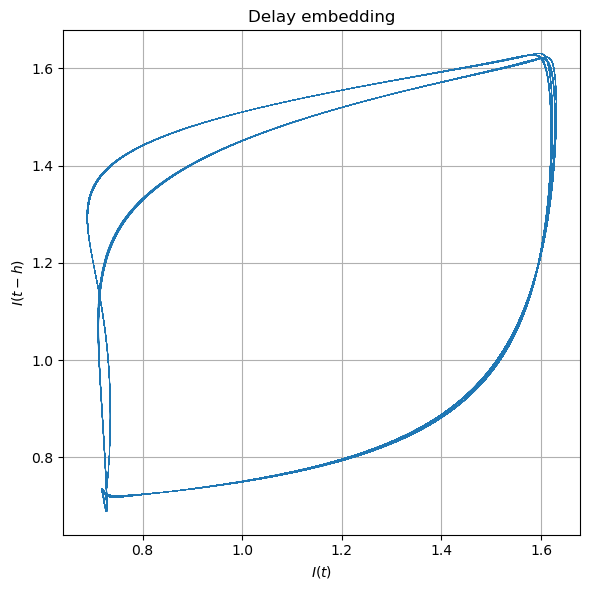

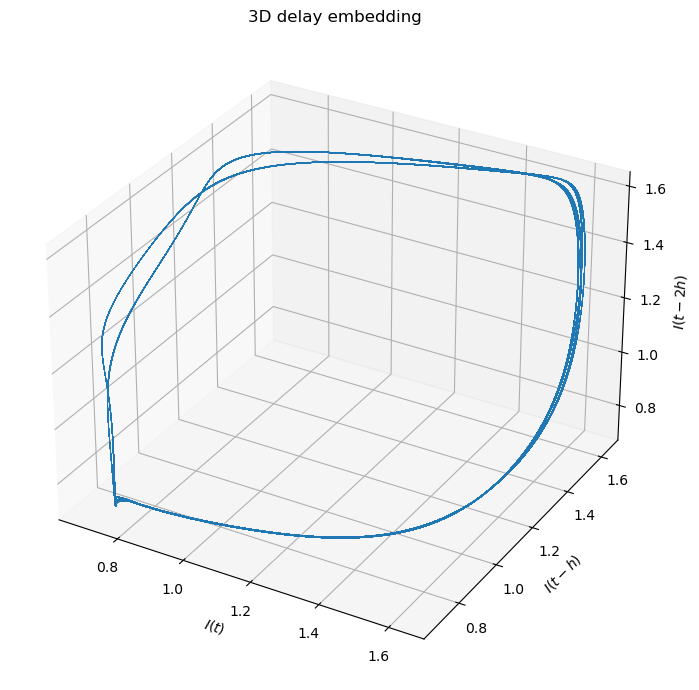

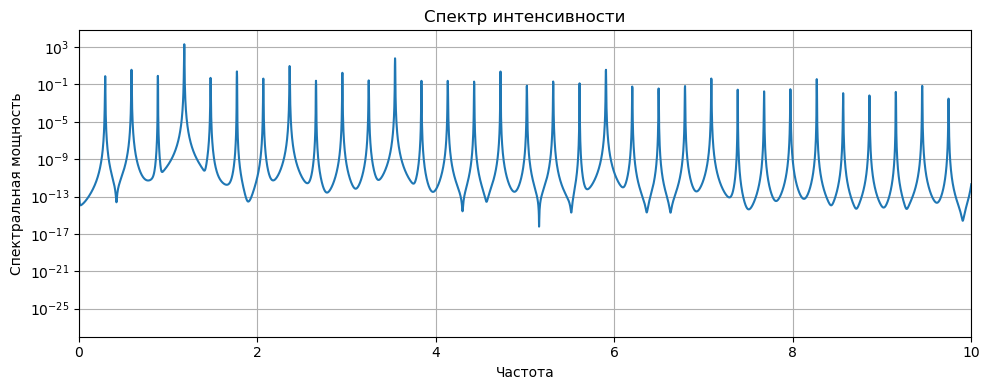

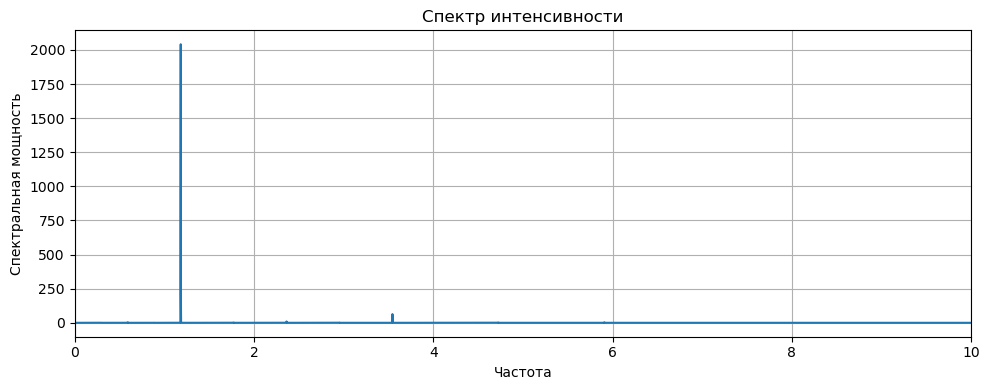

In [2]:
# ==================================================
# I(t), theta(t)
# ==================================================

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(t_plot, I_plot)
plt.xlabel('t')
plt.ylabel(r'$I=R^2$')
plt.title('Intensity')
plt.grid(True)
plt.xlim(980, 1000)

plt.subplot(1, 2, 2)
plt.plot(
    t_plot,
    omega_inst
)

plt.xlabel('t')
plt.ylabel(r'$d\theta/dt$')

plt.title('мгновенная частота генерации')

plt.grid(True)
plt.tight_layout()
plt.xlim(980, 1000)
plt.show()

# ==================================================
# I(t) delta teta(t)
# ==================================================
delay_steps = int(h / dt)

delta_theta = theta_plot[delay_steps:] - theta_plot[:-delay_steps]
I_delta = I_plot[delay_steps:]

plt.figure(figsize=(6,6))

plt.plot(
    I_delta,
    delta_theta,
    linewidth=0.3
)

plt.xlabel(r'$I$')
plt.ylabel(r'$\Delta\theta$')

plt.title(r'$(I,\Delta\theta)$')

plt.grid(True)
plt.tight_layout()
plt.show()

# ==================================================
# delay embedding 2D
# ==================================================

delay_steps = int(h / dt)

if delay_steps < len(I_plot):

    plt.figure(figsize=(6, 6))

    plt.plot(
        I_plot[delay_steps:],
        I_plot[:-delay_steps],
        linewidth=0.3
    )

    plt.xlabel(r'$I(t)$')
    plt.ylabel(r'$I(t-h)$')

    plt.title('Delay embedding')

    plt.grid(True)
    plt.tight_layout()
    plt.show()

# ==================================================
# delay embedding 3D
# ==================================================

if 2 * delay_steps < len(I_plot):

    x = I_plot[2 * delay_steps:]
    y = I_plot[delay_steps:-delay_steps]
    z = I_plot[:-2 * delay_steps]

    fig = plt.figure(figsize=(8, 7))

    ax = fig.add_subplot(
        111,
        projection='3d'
    )

    ax.plot(
        x,
        y,
        z,
        linewidth=0.3
    )

    ax.set_xlabel(r'$I(t)$')
    ax.set_ylabel(r'$I(t-h)$')
    ax.set_zlabel(r'$I(t-2h)$')

    ax.set_title('3D delay embedding')

    plt.tight_layout()
    plt.show()

# ==================================================
# спектр интенсивности
# ==================================================

signal = I_plot - np.mean(I_plot)

N = len(signal)

window = windows.hann(N)

signal_w = signal * window

fft_vals = np.fft.rfft(signal_w)

freq = np.fft.rfftfreq(
    N,
    dt
)

spec = np.abs(fft_vals) ** 2

spec /= np.sum(window**2)

plt.figure(figsize=(10, 4))

plt.plot(
    freq,
    spec
)

plt.xlim(0, 10)

plt.yscale('log')

plt.xlabel('Частота')
plt.ylabel('Спектральная мощность')

plt.title('Спектр интенсивности')

plt.grid(True)
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 4))

plt.plot(
    freq,
    spec
)

plt.xlim(0, 10)

plt.xlabel('Частота')
plt.ylabel('Спектральная мощность')

plt.title('Спектр интенсивности')

plt.grid(True)
plt.tight_layout()
plt.show()

[ 1.182  3.544  2.362  0.59   5.908  1.772  4.726  2.954  0.886  0.296
  1.476  7.088  2.068  8.27   3.248  2.658  3.84   4.134  5.316  4.43
  5.612  5.022  9.452  6.794  6.202  6.498  7.974  7.384 10.634]

Главные пики спектра:

1: f = 1.182000, power = 2.041909e+03
2: f = 3.544000, power = 6.369975e+01
3: f = 2.362000, power = 9.522974e+00
4: f = 0.590000, power = 3.768051e+00
5: f = 5.908000, power = 3.750466e+00
6: f = 1.772000, power = 2.512500e+00
7: f = 4.726000, power = 2.450809e+00
8: f = 2.954000, power = 1.790994e+00
9: f = 0.886000, power = 8.390458e-01
10: f = 0.296000, power = 7.760582e-01
11: f = 1.476000, power = 5.118163e-01
12: f = 7.088000, power = 4.338864e-01
13: f = 2.068000, power = 4.262928e-01
14: f = 8.270000, power = 3.738497e-01
15: f = 3.248000, power = 2.728235e-01
16: f = 2.658000, power = 2.521065e-01
17: f = 3.840000, power = 2.470904e-01
18: f = 4.134000, power = 2.462365e-01
19: f = 5.316000, power = 2.083856e-01
20: f = 4.430000, power = 2.039378e-01

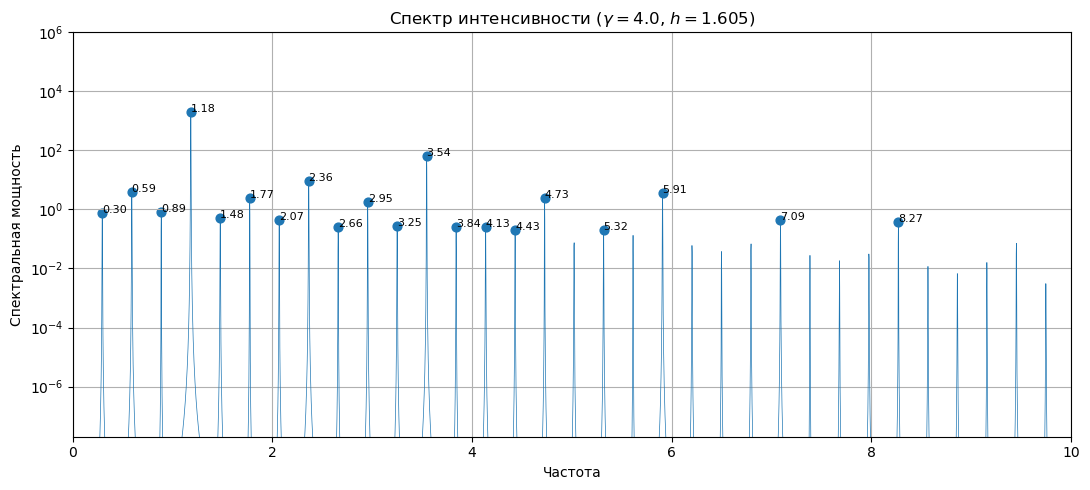

In [3]:
# ============================================================
#                 СПЕКТР МОЩНОСТИ
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# ------------------------------------------------------------
# Сигнал интенсивности
# ------------------------------------------------------------

signal = I_plot - np.mean(I_plot)

N = len(signal)

# ------------------------------------------------------------
# Окно Хэннинга
# ------------------------------------------------------------

window = np.hanning(N)

signal_w = signal * window

# ------------------------------------------------------------
# FFT
# ------------------------------------------------------------

freq = np.fft.rfftfreq(N, dt)

fft_vals = np.fft.rfft(signal_w)

spec = np.abs(fft_vals)**2

# Нормировка
spec /= np.sum(window**2)

# ============================================================
#                 ПОИСК ГЛАВНЫХ ПИКОВ
# ============================================================

# Исключаем нулевую частоту
mask = freq > 1e-6

freq_nonzero = freq[mask]
spec_nonzero = spec[mask]

# ------------------------------------------------------------
# Поиск пиков
# prominence можно менять
# ------------------------------------------------------------

peaks, properties = find_peaks(
    spec_nonzero,
    prominence=np.max(spec_nonzero) * 1e-5
)

# ------------------------------------------------------------
# Сортировка по мощности
# ------------------------------------------------------------

peak_freqs = freq_nonzero[peaks]
peak_powers = spec_nonzero[peaks]

order = np.argsort(peak_powers)[::-1]

peak_freqs = peak_freqs[order]
peak_powers = peak_powers[order]
print(peak_freqs)
# ------------------------------------------------------------
# Берём 10 главных пиков
# ------------------------------------------------------------

n_show = min(20, len(peak_freqs))

peak_freqs = peak_freqs[:n_show]
peak_powers = peak_powers[:n_show]

# ============================================================
#                 ВЫВОД ПИКОВ
# ============================================================

print("\nГлавные пики спектра:\n")

for i in range(n_show):

    print(
        f"{i+1}: "
        f"f = {peak_freqs[i]:.6f}, "
        f"power = {peak_powers[i]:.6e}"
    )

# ------------------------------------------------------------
# Отношения частот
# ------------------------------------------------------------

f0 = peak_freqs[0]

print("\nОтношения частот:\n")

for i in range(1, n_show):

    ratio = peak_freqs[i] / f0

    print(
        f"{peak_freqs[i]:.4f} / "
        f"{f0:.4f} = {ratio:.4f}"
    )

# ============================================================
#                 ГРАФИК СПЕКТРА
# ============================================================

plt.figure(figsize=(11, 5))

plt.plot(freq, spec, linewidth=0.5)

# отметим пики
plt.scatter(
    peak_freqs,
    peak_powers,
    s=40
)

# подписи к главным пикам
for i in range(n_show):

    plt.text(
        peak_freqs[i],
        peak_powers[i],
        f'{peak_freqs[i]:.2f}',
        fontsize=8
    )

plt.xlim(0, 10)
plt.ylim(2e-8,1e+6)
# логарифмический масштаб
plt.yscale('log')

plt.xlabel('Частота')
plt.ylabel('Спектральная мощность')

plt.title(
    rf'Спектр интенсивности '
    rf'($\gamma={gamma}$, $h={h}$)'
)

plt.grid(True)

plt.tight_layout()

plt.show()

# Отображение последования максимумов

Для исследования структуры колебаний используется отображение последования локальных максимумов интенсивности.

Метод основан на анализе последовательности

$$
I_{\max}^{(1)},
I_{\max}^{(2)},
I_{\max}^{(3)},
\dots
$$

где

$$
I_{\max}^{(n)}
$$

обозначает значение очередного локального максимума интенсивности

$$
I(t)=R^2(t).
$$

---

# Выделение максимумов

Сначала из временного ряда удаляется переходный процесс.

После этого находятся локальные максимумы интенсивности с помощью функции

```python
find_peaks()
```

Для отбора физических максимумов используются дополнительные критерии.

---

## Параметр distance

```python
distance = 196
```

Задаёт минимальное расстояние между соседними максимумами в количестве временных шагов.

Если значение слишком мало, алгоритм может принимать небольшие локальные флуктуации за самостоятельные максимумы.

Если значение слишком велико, часть реальных максимумов может быть пропущена.

При изменении параметров системы может потребоваться подбор нового значения.

---

## Параметр prominence

```python
prominence = 0.1*np.std(I_transient_free)
```

Определяет минимальную выраженность максимума относительно окружающего сигнала.

Фактически данный параметр позволяет фильтровать шумовые пики и мелкие колебания.

Увеличение коэффициента приводит к тому, что учитываются только наиболее заметные максимумы.

Уменьшение коэффициента позволяет обнаруживать более слабые пики.

Например:

```python
prominence = 0.05*np.std(I_transient_free)
```

или

```python
prominence = 0.2*np.std(I_transient_free)
```

---

# Отображение Пуанкаре для максимумов

После выделения последовательности максимумов строятся точки

$$
\left(
I_{\max}^{(n)},
I_{\max}^{(n+1)}
\right).
$$

Каждая точка отображает связь между двумя последовательными максимумами интенсивности.

Такое представление часто называют:

- отображением последования;
- next-map;
- одномерным отображением Пуанкаре.

---

# Интерпретация графика

## Периодический режим

Если все максимумы одинаковы,

$$
I_{\max}^{(n+1)}
=
I_{\max}^{(n)},
$$

то все точки ложатся в одну точку на биссектрисе.

Это соответствует устойчивому периодическому режиму.

---

## Период-2

Если максимумы чередуются между двумя значениями,

$$
A \rightarrow B \rightarrow A \rightarrow B,
$$

то на графике возникают две точки.

Такой режим соответствует удвоению периода.

---

## Периодический режим высокого порядка

Если цикл содержит несколько различных максимумов, появляется конечное число отдельных точек.

Число точек связано с периодом колебаний.

---

## Квазипериодический режим

Точки располагаются вдоль непрерывной кривой.

Это свидетельствует о наличии нескольких конкурирующих частот в системе.

---

## Хаотический режим

Точки заполняют некоторую область плоскости.

Появляется характерное облако точек или фрактальная структура.

Такое поведение указывает на хаотическую динамику.

---

# Биссектриса

На график дополнительно наносится линия

$$
I_{\max}^{(n+1)}
=
I_{\max}^{(n)}.
$$

Она отображается красным пунктиром и называется биссектрисой.

Биссектриса служит вспомогательным ориентиром для анализа неподвижных точек отображения.

Если точки располагаются на биссектрисе, то выполняется условие

$$
I_{\max}^{(n+1)}
=
I_{\max}^{(n)},
$$

то есть соседние максимумы совпадают.

Для периодических режимов значительная часть точек располагается непосредственно на этой линии или вблизи неё.

---

# Что можно изменять

Пользователь может настраивать следующие параметры анализа:

| Параметр | Назначение |
|-----------|-----------|
| `distance` | минимальное расстояние между максимумами |
| `prominence` | минимальная выраженность максимума |
| доля отбрасываемого переходного процесса | выбор установившегося режима |

Например:

```python
I_transient_free = I_plot[len(I_plot)//2:]
```

оставляет последние 50% временного ряда.

Для более длинных переходных процессов можно использовать

```python
I_transient_free = I_plot[3*len(I_plot)//4:]
```

что оставляет только последние 25% траектории.

---

# Практические рекомендации

Если отображение выглядит случайным или содержит слишком много точек, рекомендуется:

1. увеличить длину моделирования `t_max`;
2. увеличить отбрасываемую часть переходного процесса;
3. подобрать параметры `distance` и `prominence`;
4. сравнить результат с временными реализациями и спектром мощности.

Совместный анализ отображения последования, спектра и фазовых портретов позволяет надёжно различать периодические, квазипериодические и хаотические режимы генерации.

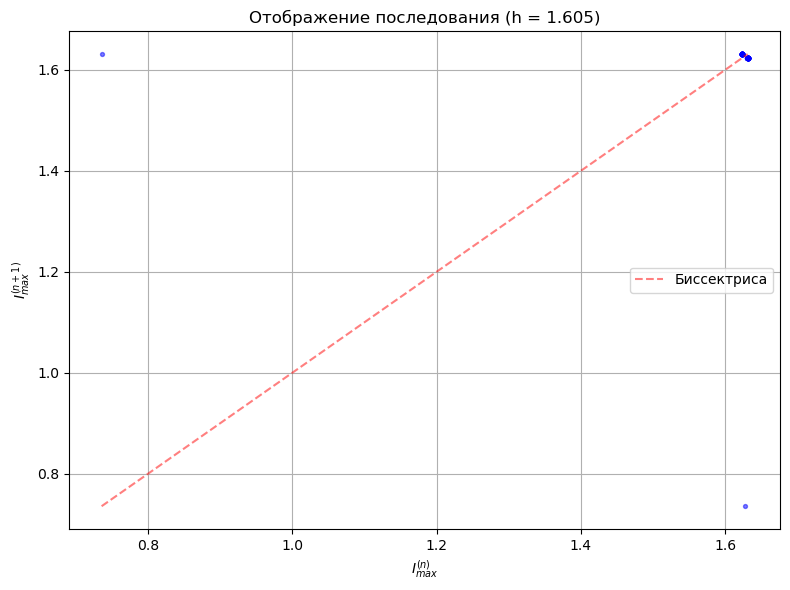

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# Предположим, у вас есть массив t и I_plot (интенсивность |E|^2)
# ВАЖНО: Используйте только установившийся режим! Отбросьте начальный транзиент.
# Например, оставьте последние 50% данных:
I_transient_free = I_plot[len(I_plot)//2:]

# 1. Находим локальные максимумы
peaks_idx, _ = find_peaks(
    I_transient_free,
    distance=100,
    #prominence=0.1*np.std(I_transient_free)
)
maxima = I_transient_free[peaks_idx]

# 2. Строим отображение Пуанкаре (Next-Map)
plt.figure(figsize=(8, 6))
plt.scatter(maxima[:-1], maxima[1:], s=8, alpha=0.5, color='blue')
plt.xlabel('$I_{max}^{(n)}$')
plt.ylabel('$I_{max}^{(n+1)}$')
plt.title(f'Отображение последования (h = {h})')
plt.grid(True)
plt.plot([min(maxima), max(maxima)], [min(maxima), max(maxima)], 'r--', alpha=0.5, label='Биссектриса')
plt.legend()
plt.tight_layout()
plt.show()

## Оценка старшего показателя Ляпунова методом Розенштейна

Данная ячейка реализует вычисление старшего показателя Ляпунова по временному ряду интенсивности лазерного излучения методом Розенштейна. Метод позволяет определить наличие чувствительной зависимости от начальных условий и тем самым выявить хаотический режим динамики.

### Основная идея метода

По одномерному временному ряду $$I(t)$$ строится реконструированное фазовое пространство с использованием теоремы Такенса. Каждая точка вложения имеет вид

$$
\mathbf{X}*i =
\left(
I_i,,
I*{i+\tau},,
I_{i+2\tau},,
\dots,,
I_{i+(m-1)\tau}
\right),
$$

где:

* $m$ — размерность вложения;
* $\tau$ — задержка вложения.

Для каждой точки находится ближайший сосед, удовлетворяющий условию окна Тейлера, что исключает выбор соседей, принадлежащих одной и той же локальной траектории.

После выбора соседних точек анализируется рост расстояния между соответствующими траекториями:

$$
d_i(k)=
\left|
\mathbf{X}_{i+k}
\mathbf{X}_{j+k}
\right|.
$$

Для хаотической системы среднее расстояние между близкими траекториями растёт экспоненциально:

$$
d(k)\sim d(0)e^{\lambda k\Delta t},
$$

где $\lambda$ — старший показатель Ляпунова.

После логарифмирования получаем линейную зависимость

$$
\ln d(k)
$$
========
$$
\ln d(0)
+
\lambda k\Delta t.
$$

Следовательно, коэффициент наклона линейного участка графика

$$
\langle \ln d(k) \rangle
$$

является оценкой старшего показателя Ляпунова.

### Используемые параметры

* **m** — размерность вложения;
* **tau** — временная задержка при построении вложения;
* **theiler** — окно Тейлера для исключения коррелированных соседей;
* **max_k** — максимальная длина эволюции соседних траекторий;
* **fit_start**, **fit_end** — границы линейного участка, используемого для аппроксимации.

Для системы Ланга–Кобаяши рекомендуется выбирать окно Тейлера больше времени задержки:

$$
W_{\mathrm{Theiler}} > \frac{h}{\Delta t},
$$

где $$h$$ — время внешней обратной связи.

Параметр вложения обычно выбирается порядка

$$
\tau \approx
(0.1 \ldots 0.5)
\frac{h}{\Delta t}.
$$

### Интерпретация результата

* $$\lambda > 0$$ — хаотический режим;
* $$\lambda \approx 0$$ — квазипериодическая динамика;
* $$\lambda < 0$$ — устойчивый периодический режим.

Дополнительно вычисляется характерное время расхождения близких траекторий

$$
T_d=\frac{\ln 2}{\lambda},
$$

которое показывает время удвоения начального возмущения в хаотическом режиме.

На графике отображается зависимость

$$
\langle \ln d(t)\rangle
$$

от времени, а также линейная аппроксимация выбранного участка, наклон которой определяет оценку старшего показателя Ляпунова.


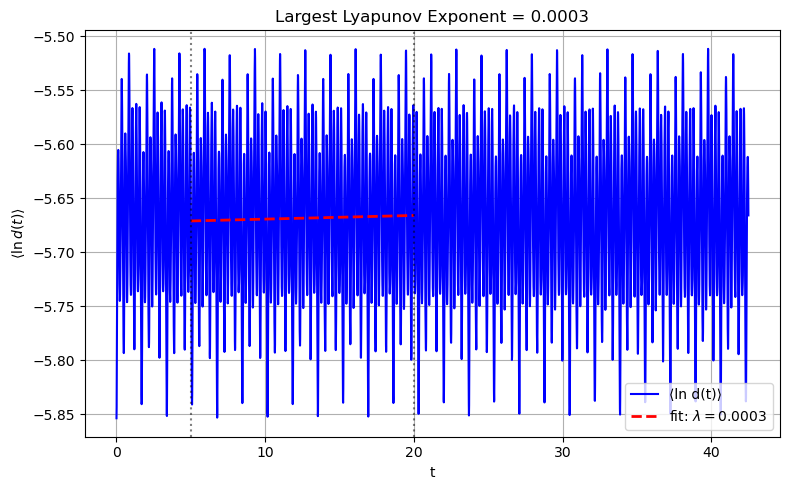

λ = 0.000341 [1/ед.времени]
Время удвоения: 2030.5350 (при λ>0)


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree

def delay_embed(x, m=6, tau=10):
    x = np.asarray(x, dtype=float)
    N = len(x)
    M = N - (m - 1) * tau
    if M <= 0:
        raise ValueError("Недостаточно данных для вложения с выбранными m и tau.")
    emb = np.empty((M, m))
    for k in range(m):
        emb[:, k] = x[k * tau:k * tau + M]
    return emb

def largest_lyapunov_rosenstein(
    signal,
    dt,
    m=6,
    tau=10,
    theiler=50,
    max_k=200,
    fit_start=10,
    fit_end=60
):
    if fit_end > max_k:
        raise ValueError("fit_end не может превышать max_k.")
        
    signal = signal - np.mean(signal)
    X = delay_embed(signal, m=m, tau=tau)
    N = len(X)
    
    tree = cKDTree(X)
    neigh_ind = np.full(N, -1, dtype=int)
    
    for i in range(N):
        dists, inds = tree.query(X[i], k=min(30, N))
        for j in inds[1:]:
            if abs(j - i) > theiler:
                neigh_ind[i] = j
                break
                
    valid = np.where(neigh_ind >= 0)[0]
    if len(valid) == 0:
        raise RuntimeError("Не найдено ни одной пары соседей, удовлетворяющих условию Тейлера.")
        
    div = np.zeros(max_k)
    counts = np.zeros(max_k)
    
    for i in valid:
        j = neigh_ind[i]
        end_idx = min(N - i, N - j, max_k)
        if end_idx <= 0:
            continue
        diffs = X[i:i+end_idx] - X[j:j+end_idx]
        d = np.linalg.norm(diffs, axis=1)
        mask = d > 1e-14
        
        # ИСПРАВЛЕНИЕ: безопасная индексация для in-place обновления
        idx = np.arange(end_idx)[mask]
        div[idx] += np.log(d[mask])
        counts[idx] += 1
        
    mask_counts = counts > 0
    div[mask_counts] /= counts[mask_counts]
    
    t_k = np.arange(max_k) * dt
    
    valid_fit = (fit_start < fit_end) & (fit_end <= max_k)
    if not valid_fit:
        raise ValueError("Некорректный диапазон подгонки.")
        
    coeffs = np.polyfit(t_k[fit_start:fit_end], div[fit_start:fit_end], 1)
    lce = coeffs[0]
    
    plt.figure(figsize=(8, 5))
    plt.plot(t_k, div, 'b-', linewidth=1.5, label='⟨ln d(t)⟩')
    plt.plot(t_k[fit_start:fit_end], 
             np.polyval(coeffs, t_k[fit_start:fit_end]), 
             'r--', linewidth=2, label=rf'fit: $\lambda={lce:.4f}$')
    plt.axvline(t_k[fit_start], color='k', linestyle=':', alpha=0.5)
    plt.axvline(t_k[fit_end], color='k', linestyle=':', alpha=0.5)
    plt.xlabel('t')
    plt.ylabel(r'$\langle \ln d(t)\rangle$')
    plt.title(f'Largest Lyapunov Exponent = {lce:.4f}')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    print(f"λ = {lce:.6f} [1/ед.времени]")
    print(f"Время удвоения: {np.log(2)/abs(lce):.4f} (при λ>0)")
    
    return lce

# Параметры, специфичные для системы Ланга–Кобаяши:
# theiler > h/dt (окно Тейлера должно покрывать время задержки)
# tau ≈ 0.1h/dt ... 0.5h/dt (задержка вложения)
lce = largest_lyapunov_rosenstein(
    signal=I_plot,
    dt=dt,
    m=8,
    tau=50,
    theiler=150,
    max_k=4250,
    fit_start=500,
    fit_end=2000
)